# Garmin Stress Prediction Pipeline

This notebook loads and preprocesses Garmin study data, integrates sleep metrics, handles missing values, and aggregates time-series data. 
Then, it builds feature/target datasets for stress prediction, performs correlation analysis, and trains classification models to forecast stress levels. The workflow includes model comparison, evaluation, and multiple visualizations to explore stress patterns across users, rooms, and time.

In [61]:
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pypalettes import load_cmap
load_dotenv()

True

In [62]:
study_df_path = os.getenv("STUDY_DF_PATH")
sleep_df_path = os.getenv("SLEEP_DF_PATH")
save_path = os.getenv("SAVE_PATH")

Import study/work DataFrame

In [63]:
df = pd.read_csv(study_df_path)

In [64]:
# Raw dataset table before preprocessing
df_raw = df.copy()
df_raw.head(5)

,timestamp_local,garmin_id,room,hr,stress_score,body_battery,activity_type,intensity,steps,temperature_DHT22_C,humidity_DHT22_%,CO2_ppm,TVOC_ppb,respiration_rate
0,2026-01-11 09:00:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,home,NaN,20.00,35.00,NaN,NaN,NaN,19.40,52.60,402.00,0.00,NaN
1,2026-01-11 09:00:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,home,NaN,20.00,35.00,NaN,NaN,NaN,19.40,52.60,402.00,0.00,NaN
2,2026-01-11 09:00:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,home,68.00,NaN,NaN,NaN,NaN,NaN,19.40,52.60,402.00,0.00,NaN
3,2026-01-11 09:01:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,home,69.00,NaN,NaN,NaN,NaN,NaN,19.40,52.60,402.00,0.00,NaN
4,2026-01-11 09:02:00,66c2c60b-769f-4d63-b470-a3ae5c6ed251,home,71.00,NaN,NaN,NaN,NaN,NaN,19.40,52.60,402.00,0.00,NaN


## Exploratory Data Analysis
Exploration of the dataframe that contains phisological data and environmental data during study session.

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13790 entries, 0 to 13789
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp_local      13790 non-null  object 
 1   garmin_id            13790 non-null  object 
 2   room                 13790 non-null  object 
 3   hr                   11237 non-null  float64
 4   stress_score         5158 non-null   float64
 5   body_battery         5158 non-null   float64
 6   activity_type        1018 non-null   object 
 7   intensity            1018 non-null   object 
 8   steps                1018 non-null   float64
 9   temperature_DHT22_C  13790 non-null  float64
 10  humidity_DHT22_%     13790 non-null  float64
 11  CO2_ppm              13790 non-null  float64
 12  TVOC_ppb             13790 non-null  float64
 13  respiration_rate     1342 non-null   float64
dtypes: float64(9), object(5)
memory usage: 1.5+ MB


In [66]:
df["activity_type"].unique()

array([nan, 'SEDENTARY'], dtype=object)

In [67]:
df["garmin_id"].unique()

array(['66c2c60b-769f-4d63-b470-a3ae5c6ed251',
       '8d738deb-db44-405e-ac6a-ce73135eb434',
       'add44d45-b0dd-44be-b700-16738b6f7f10'], dtype=object)

In [68]:
df["room"].unique()

array(['home', 'library', 'lab'], dtype=object)

In [69]:
df["intensity"].unique()

array([nan, 'SEDENTARY'], dtype=object)

In [70]:
df["steps"].unique()

array([nan,  0.])

In [71]:
df.isna().sum()

timestamp_local            0
garmin_id                  0
room                       0
hr                      2553
stress_score            8632
body_battery            8632
activity_type          12772
intensity              12772
steps                  12772
temperature_DHT22_C        0
humidity_DHT22_%           0
CO2_ppm                    0
TVOC_ppb                   0
respiration_rate       12448
dtype: int64

Backward fill missing values (NaN)

In [72]:
df["stress_score"] = df["stress_score"].bfill()

In [73]:
df["body_battery"] = df["body_battery"].bfill()

In [74]:
df["hr"] = df["hr"].bfill()

In [75]:
df["respiration_rate"] = df["respiration_rate"].bfill()


In [76]:
df.isna().sum()

timestamp_local            0
garmin_id                  0
room                       0
hr                         0
stress_score               3
body_battery               3
activity_type          12772
intensity              12772
steps                  12772
temperature_DHT22_C        0
humidity_DHT22_%           0
CO2_ppm                    0
TVOC_ppb                   0
respiration_rate        1171
dtype: int64

Sort the DataFrame by `garmin_id` and timestamp

In [77]:
# Convert timestamp to datetime and round to minute
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'])
df['timestamp_minute'] = df['timestamp_local'].dt.floor('T')  # Round to minute

# Group by garmin_id and minute, aggregating with mean for numeric columns
agg_dict = {
    'stress_score': 'mean',
    'body_battery': 'mean',
    'hr': 'mean',
    'respiration_rate': 'mean',
    'temperature_DHT22_C': 'mean',
    'humidity_DHT22_%': 'mean',
    'CO2_ppm': 'mean',
    'TVOC_ppb': 'mean',
    'room': 'first',  # Keep first value for categorical
    'activity_type': 'first',
    'intensity': 'first',
    'steps': 'sum'  # Sum steps within the same minute
}

df = df.groupby(['garmin_id', 'timestamp_minute']).agg(agg_dict).reset_index()
df = df.rename(columns={'timestamp_minute': 'timestamp_local'})
df = df.sort_values(['garmin_id', 'timestamp_local']).reset_index(drop=True)

## Sleep Data Integration
This section loads nightly sleep records, aggregates them per user and date, fills missing nights via interpolation, computes rolling baselines and ratios, then shifts and merges sleep features into the main dataset for next-day stress prediction.

Load and Preprocess Sleep Data

In [78]:
sleep_df = pd.read_csv(sleep_df_path)
sleep_df['timestamp_local'] = pd.to_datetime(sleep_df['timestamp_local'])
sleep_df['sleep_date'] = sleep_df['timestamp_local'].dt.date

We aggregate raw sleep data by garmin_id and sleep_date. This step ensures we have a single set of representative metrics (mean scores and max durations) for each night of sleep.

In [79]:
sleep_daily = (
    sleep_df
    .groupby(['garmin_id', 'sleep_date'], as_index=False)
    .agg(
        sleep_score_prev=('sleep_score', 'mean'),
        sleep_duration_prev=('total_sleep_duration', 'max'),
        deep_sleep_duration_prev=('deep_sleep_duration', 'max'),
        sleep_respiration_rate_prev=('sleep_respiration_rate', 'mean')
    )
)
sleep_daily['sleep_date'] = pd.to_datetime(sleep_daily['sleep_date'])

Per user data continuity handling: reindex the dates, interpolate missing values, and calculate a 14-day rolling median to establish a personal sleep baseline for each user.

- Ensures all dates between the first and last recorded sleep are present.

- Fills missing values using linear interpolation.

- Calculates a 14-day rolling median to establish a reference sleep_score and computes the performance ratio.

In [80]:
full_sleep_df = pd.DataFrame()

for user_id, user_data in sleep_daily.groupby('garmin_id'):
    min_date = user_data['sleep_date'].min()
    max_date = user_data['sleep_date'].max()
    all_dates = pd.date_range(start=min_date, end=max_date, freq='D')
    
    user_data = user_data.set_index('sleep_date').reindex(all_dates)
    user_data['garmin_id'] = user_id
    
    cols_to_interpolate = [
        'sleep_score_prev', 'sleep_duration_prev', 
        'deep_sleep_duration_prev', 'sleep_respiration_rate_prev'
    ]
    user_data[cols_to_interpolate] = (
        user_data[cols_to_interpolate]
        .interpolate(method='linear', limit_direction='both')
        .ffill()
        .bfill()
    )
    
    user_data['sleep_score_baseline'] = (
        user_data['sleep_score_prev']
        .rolling(window=14, min_periods=1)
        .median()
        .ffill()
        .bfill()
    )
    
    user_data = user_data.reset_index().rename(columns={'index': 'sleep_date'})
    full_sleep_df = pd.concat([full_sleep_df, user_data], ignore_index=True)


full_sleep_df['sleep_score_ratio'] = (full_sleep_df['sleep_score_prev'] / 
                                      full_sleep_df['sleep_score_baseline']).fillna(1.0)


Since sleep on "night N" typically impacts performances of "day N+1", we shift the sleep metrics forward by one day to align them correctly with daily physiological data.

In [81]:
# Shift Dates for Merging
full_sleep_df['data_date'] = full_sleep_df['sleep_date'].dt.date + pd.Timedelta(days=1)

df['timestamp_local'] = pd.to_datetime(df['timestamp_local'])
df['data_date'] = df['timestamp_local'].dt.date

Merging preprocessed sleep features into the main dataframe.

In [82]:
# Merge with Main DataFrame
sleep_cols = [
    'sleep_score_prev', 'sleep_duration_prev', 'deep_sleep_duration_prev',
    'sleep_respiration_rate_prev', 'sleep_score_baseline', 'sleep_score_ratio'
]

df = df.merge(
    full_sleep_df[[
        'garmin_id',
        'data_date'] +  sleep_cols],
    on=['garmin_id', 'data_date'],
    how='left'
)


Final "forward-fill" and "back-fill" is applied to handle any remaining gaps, ensuring a clean dataset for modeling.

In [83]:
df[sleep_cols] = df.groupby('garmin_id')[sleep_cols].ffill().bfill()

# Check results
print("Missing values after merge and fill:")
print(df[sleep_cols].isna().sum())
print("\nShape:", df.shape)

Missing values after merge and fill:
sleep_score_prev               1080
sleep_duration_prev            1080
deep_sleep_duration_prev       1080
sleep_respiration_rate_prev    1080
sleep_score_baseline           1080
sleep_score_ratio              1080
dtype: int64

Shape: (6615, 21)


## Model Preparation

Create the training dataframe.

Define `TARGET` and `FEATURES`

In [84]:
TARGET = "stress_score"
FEATURES = [
    "body_battery",
    "hr",
    "respiration_rate",
    "temperature_DHT22_C",
    "humidity_DHT22_%",
    "CO2_ppm",
    "TVOC_ppb",
    "sleep_score_prev",
    "sleep_score_baseline",
    "sleep_score_ratio"
 ]
#FEATURES = ["hr", "respiration_rate", "temperature_DHT22_C", "humidity_DHT22_%", "CO2_ppm", "TVOC_ppb"]
#FEATURES = ["respiration_rate", "temperature_DHT22_C", "humidity_DHT22_%", "CO2_ppm", "TVOC_ppb"]



In [85]:
X = df[FEATURES].copy()
y = df[TARGET].copy() 

In [86]:
# Feature + target dataset table
features_target_df = df[FEATURES + [TARGET]].copy()
features_target_df.head(5)

,body_battery,hr,respiration_rate,temperature_DHT22_C,humidity_DHT22_%,CO2_ppm,TVOC_ppb,sleep_score_prev,sleep_score_baseline,sleep_score_ratio,stress_score
0,35.00,68.00,14.72,19.40,52.60,402.00,0.00,92.00,92.00,1.00,25.33
1,35.00,69.00,14.72,19.40,52.60,402.00,0.00,92.00,92.00,1.00,36.00
2,35.00,71.00,14.72,19.40,52.60,402.00,0.00,92.00,92.00,1.00,36.00
3,35.33,68.00,14.72,19.40,52.60,402.00,0.00,92.00,92.00,1.00,32.33
4,36.00,70.00,14.72,19.40,52.60,402.00,0.00,92.00,92.00,1.00,25.00


### Target Shift
This trains the model to predict future stress from current values.
we shift the target column by five position in order to predict future stess

In [87]:
y = y.shift(periods=5)

Remove NaN values 

This step removes target NaNs created by the shift, performs an 80/20 chronological split (no shuffle), and imputes missing feature values using the training-set mean for both train and test to avoid leakage.

In [88]:
X.fillna(X.mean(), inplace = True)


# TARGET HANDLING (y)
valid_indices = ~y.isna()
X = X[valid_indices]
y = y[valid_indices]

# TEMPORAL SPLIT
split_point = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# 3. GESTIONE FEATURES (X) - IMPUTATION CORRETTA
# Compute the mean ONLY on the training set
train_mean = X_train.mean()

# Fill the training set with its mean
X_train = X_train.fillna(train_mean)

# Fill the test set with the TRAINING mean
X_test = X_test.fillna(train_mean)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (5286, 10), Test shape: (1322, 10)


In [89]:
y.fillna(y.mean(), inplace = True)

In [90]:
X

,body_battery,hr,respiration_rate,temperature_DHT22_C,humidity_DHT22_%,CO2_ppm,TVOC_ppb,sleep_score_prev,sleep_score_baseline,sleep_score_ratio
5,36.00,75.00,14.72,19.40,52.60,402.00,0.00,92.00,92.00,1.00
6,36.00,74.00,14.72,19.40,52.60,402.00,0.00,92.00,92.00,1.00
7,36.00,74.00,14.72,19.40,52.60,402.00,0.00,92.00,92.00,1.00
8,36.00,74.00,14.72,19.40,52.60,402.00,0.00,92.00,92.00,1.00
9,36.00,71.00,14.72,19.40,52.60,402.00,0.00,92.00,92.00,1.00
...,...,...,...,...,...,...,...,...,...,...
6610,17.00,75.00,16.15,19.70,49.90,400.00,0.00,60.48,79.30,0.76
6611,17.00,75.00,16.15,19.70,49.90,400.00,0.00,60.48,79.30,0.76
6612,43.00,78.00,16.15,19.70,49.90,400.00,0.00,60.48,79.30,0.76
6613,74.00,71.00,16.15,19.70,49.90,400.00,0.00,60.48,79.30,0.76


In [91]:
print(X.isna().sum())

body_battery            0
hr                      0
respiration_rate        0
temperature_DHT22_C     0
humidity_DHT22_%        0
CO2_ppm                 0
TVOC_ppb                0
sleep_score_prev        0
sleep_score_baseline    0
sleep_score_ratio       0
dtype: int64


In [92]:
print(y.isna().sum())

0


### Feature correlation

In [93]:
# df_corr = df[FEATURES + [TARGET]].corr()

In [94]:

# fig, ax = plt.subplots(figsize=(10, 10))
# cax     = ax.matshow(df_corr,cmap='coolwarm', vmin=-1, vmax=1)

# fig.colorbar(cax)
# ticks = np.arange(0,len(df_corr.columns),1)
# ax.set_xticks(ticks)

# ax.set_xticklabels(df_corr.columns)
# plt.xticks(rotation = 90)

# ax.set_yticklabels(df_corr.columns)
# ax.set_yticks(ticks)

# #---print the correlation factor---
# for i in range(df_corr.shape[1]):
#     for j in range(df_corr.shape[1]):
#         text = ax.text(j, i, round(df_corr.iloc[i][j],2),
#                        ha="center", va="center", color="w")
# plt.show()

In [95]:
cmap = load_cmap("Classic_Color_Blind")

In [96]:
# from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split

## CLASSIFICATION

We set the stress threshold to achieve a balanced target distribution, avoiding severe class imbalance that can bias classifiers toward the majority class. 

- Target: `stress_score`
- Features: 10 variables (`body_battery`, `hr`, `respiration_rate`, `temperature_DHT22_C`, `humidity_DHT22_%`, `CO2_ppm`, `TVOC_ppb`, `sleep_score_prev`, `sleep_score_baseline`, `sleep_score_ratio`)
-  Regression analysis


In [97]:
STRESS_THRESHOLD = 45

In [98]:
y_classification = (y >= STRESS_THRESHOLD).astype(int)

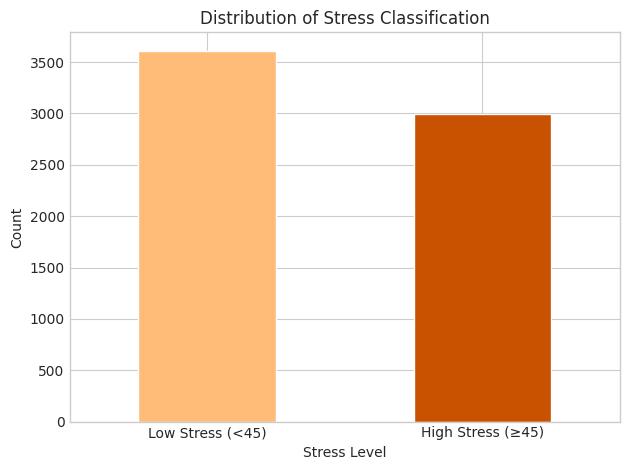

In [99]:

colors_cb = [cmap(0.8), cmap(0.5)]
y_classification.value_counts().plot(kind='bar', color=colors_cb)
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.title('Distribution of Stress Classification')
plt.xticks([0, 1], [f'Low Stress (<{STRESS_THRESHOLD})', f'High Stress (≥{STRESS_THRESHOLD})'], rotation=0)
plt.savefig((os.path.join(str(save_path), 'stress_classification_distribution.pdf')), dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [100]:
from lazypredict.Supervised import LazyClassifier

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y_classification, test_size=0.2, random_state=42)

In [102]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(5286, 10) (1322, 10) (5286,) (1322,)


In [103]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, 
                     custom_metric = None, predictions=True)

scores, predictions = clf.fit(X_train, X_test, y_train, y_test)
scores

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 2399, number of negative: 2887
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000689 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 614
[LightGBM] [Info] Number of data points in the train set: 5286, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.453840 -> initscore=-0.185166
[LightGBM] [Info] Start training from score -0.185166


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LGBMClassifier,0.80,0.79,0.79,0.79,0.38
XGBClassifier,0.79,0.79,0.79,0.79,0.12
RandomForestClassifier,0.78,0.77,0.77,0.78,0.36
ExtraTreesClassifier,0.78,0.77,0.77,0.77,0.32
KNeighborsClassifier,0.77,0.77,0.77,0.77,0.02
BaggingClassifier,0.77,0.76,0.76,0.77,0.09
LabelPropagation,0.77,0.76,0.76,0.77,0.79
LabelSpreading,0.77,0.76,0.76,0.76,1.03
DecisionTreeClassifier,0.76,0.75,0.75,0.76,0.02


In [104]:
from sklearn.metrics import confusion_matrix

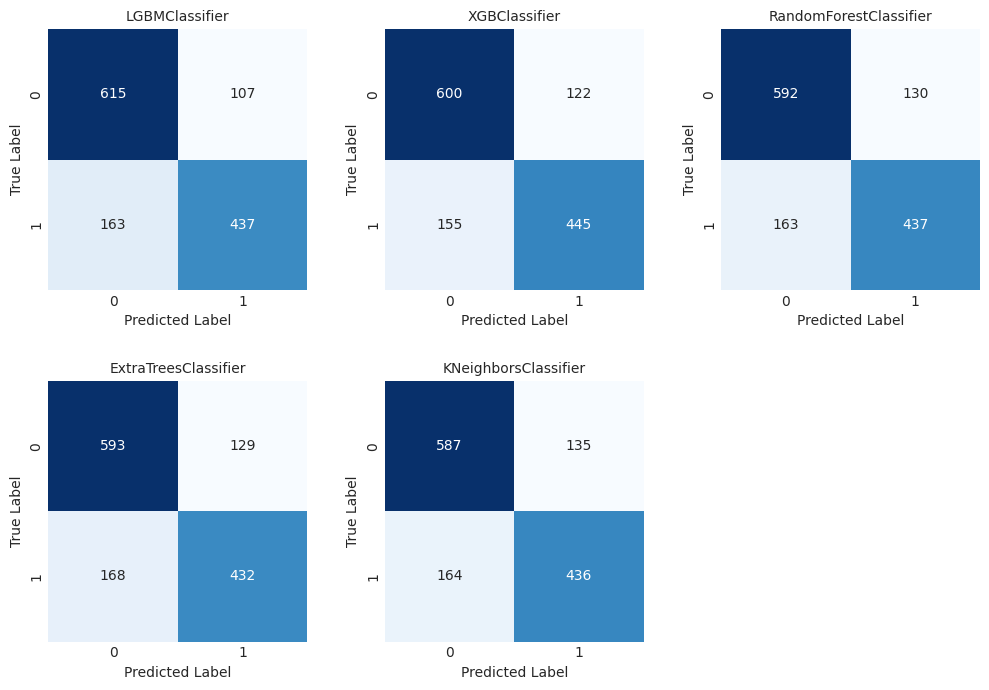

In [105]:
# Create confusion matrices for the first 5 models
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()

top_5_models = scores.head(5).index.tolist()

for idx, model_name in enumerate(top_5_models):
    y_pred = predictions[model_name]
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(model_name, fontsize=10)
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

axes[5].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.35, wspace=0.3)
plt.savefig((os.path.join(str(save_path), 'confusion_matrices.pdf')), dpi=300, bbox_inches='tight')
plt.show()

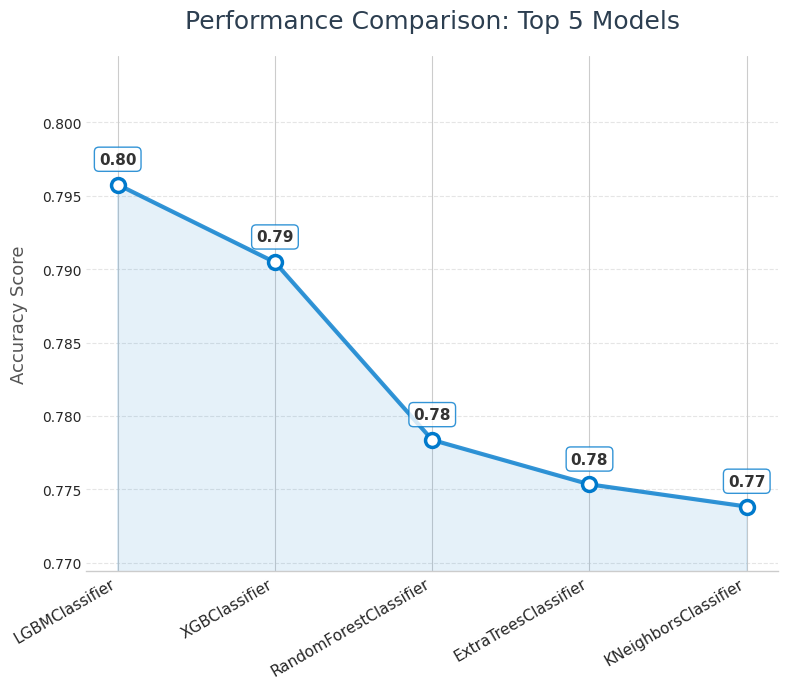


Top 5 Models Accuracy:
LGBMClassifier: 0.7958
XGBClassifier: 0.7905
RandomForestClassifier: 0.7784
ExtraTreesClassifier: 0.7753
KNeighborsClassifier: 0.7738


In [106]:
# Base style configuration
sns.set_style("whitegrid")

# --- DATA PREPARATION ---
N = 5
top_N_models = scores.head(N).index.tolist()
top_scores = scores.loc[top_N_models, 'Accuracy']

# --- CREATE PLOT ---
fig, ax = plt.subplots(figsize=(8, 7))

main_color = '#007ACC' 

ax.plot(range(len(top_N_models)), top_scores.values, 
        color=main_color, 
        linewidth=3, 
        linestyle='-', 
        alpha=0.8,
        zorder=2)

# Shaded area under the curve
ax.fill_between(range(len(top_N_models)), top_scores.values, 
                y2=min(top_scores.values) - 0.05, 
                color=main_color, 
                alpha=0.1, 
                zorder=1)

# Markers
ax.scatter(range(len(top_N_models)), top_scores.values, 
           color='white', 
           edgecolor=main_color, 
           s=100, 
           linewidth=2.5, 
           zorder=3,
           label='Accuracy')

# --- FORMATTING AND DETAILS ---

for i, acc in enumerate(top_scores.values):
    
    ax.annotate(f'{acc:.2f}', 
                xy=(i, acc), 
                xytext=(0, 15), 
                textcoords='offset points',
                ha='center', 
                fontsize=11, 
                fontweight='bold',
                color='#333333',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=main_color, alpha=0.8))

ax.set_title(f'Performance Comparison: Top {N} Models', fontsize=18,  pad=20, color='#2c3e50')
ax.set_ylabel('Accuracy Score', fontsize=13, labelpad=10, color='#555555')

ax.set_xticks(range(len(top_N_models)))
ax.set_xticklabels(top_N_models, rotation=30, ha='right', fontsize=11)

y_min = top_scores.min()
y_max = top_scores.max()
padding = (y_max - y_min) * 0.4
ax.set_ylim([y_min - padding/2, y_max + padding])

# Final cleanup
sns.despine(left=True, bottom=False)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.tick_params(axis='y', which='both', length=0)

plt.tight_layout()
plt.savefig((os.path.join(str(save_path), f'top_{N}_models_accuracy.pdf')), dpi=300, bbox_inches='tight')
plt.show()

# Print accuracy scores
print(f"\nTop {N} Models Accuracy:")
for model_name, acc in top_scores.items():
    print(f"{model_name}: {acc:.4f}")


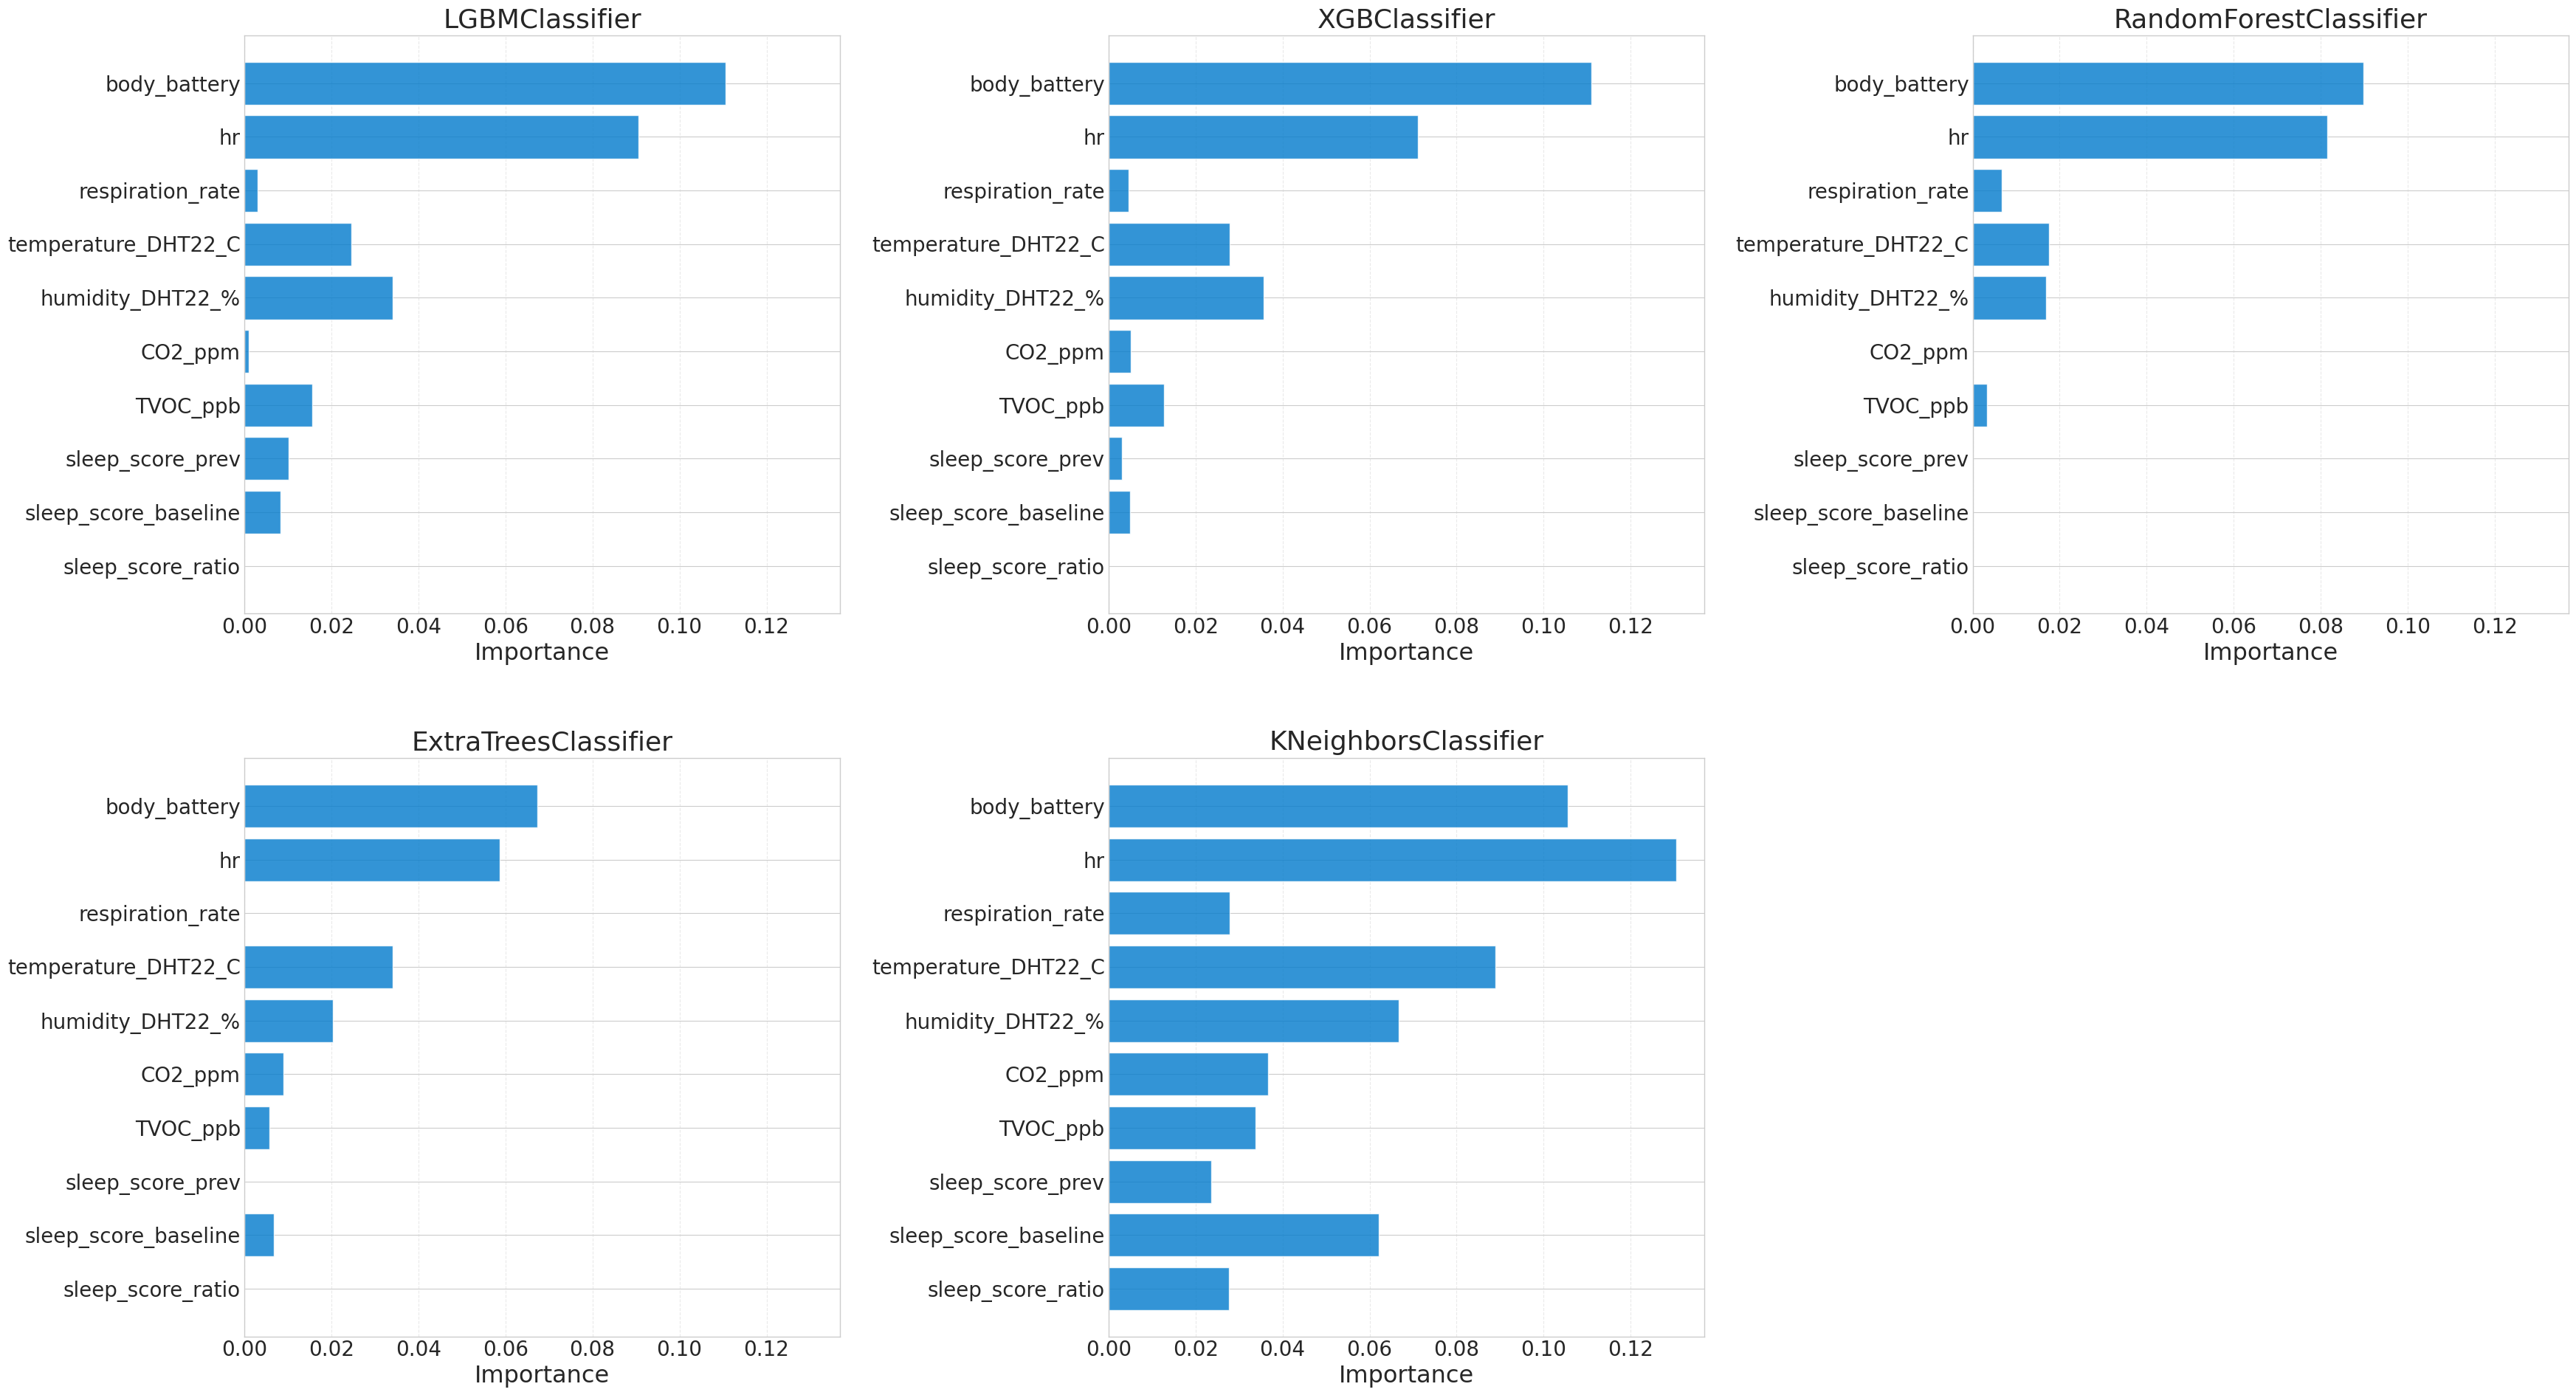

In [107]:
from sklearn.inspection import permutation_importance

N = 5

# Take the top N models from the ranking
top_N_models = scores.head(N).index.tolist()

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(2, 3, figsize=(35, 19))
axes = axes.flatten()

title_size = 26
label_size = 23
tick_size = 20
bar_color = "#007ACC"

# Harmonize the scales
all_importances = []

for idx, model_name in enumerate(top_N_models):
    # Get the trained models
    model = clf.models[model_name]
    # Compute feature importance
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    else:
       
        result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
        importances = result.importances_mean

    all_importances.append(importances)
    axes[idx].barh(FEATURES, importances, color=bar_color, alpha=0.8)
    axes[idx].set_title(model_name, fontsize=title_size, pad=8)
    axes[idx].set_xlabel("Importance", fontsize=label_size)
    axes[idx].tick_params(axis='both', labelsize=tick_size)
    axes[idx].grid(axis='x', linestyle='--', alpha=0.4)
    axes[idx].invert_yaxis()

if all_importances:
    max_importance = np.max(np.concatenate(all_importances))
    for ax in axes[:len(top_N_models)]:
        ax.set_xlim(0, max_importance * 1.05)

axes[5].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.25, wspace=0.45)
plt.savefig((os.path.join(str(save_path), f'top_{N}_models_feature_importance.pdf')), dpi=300, bbox_inches='tight')
plt.show()

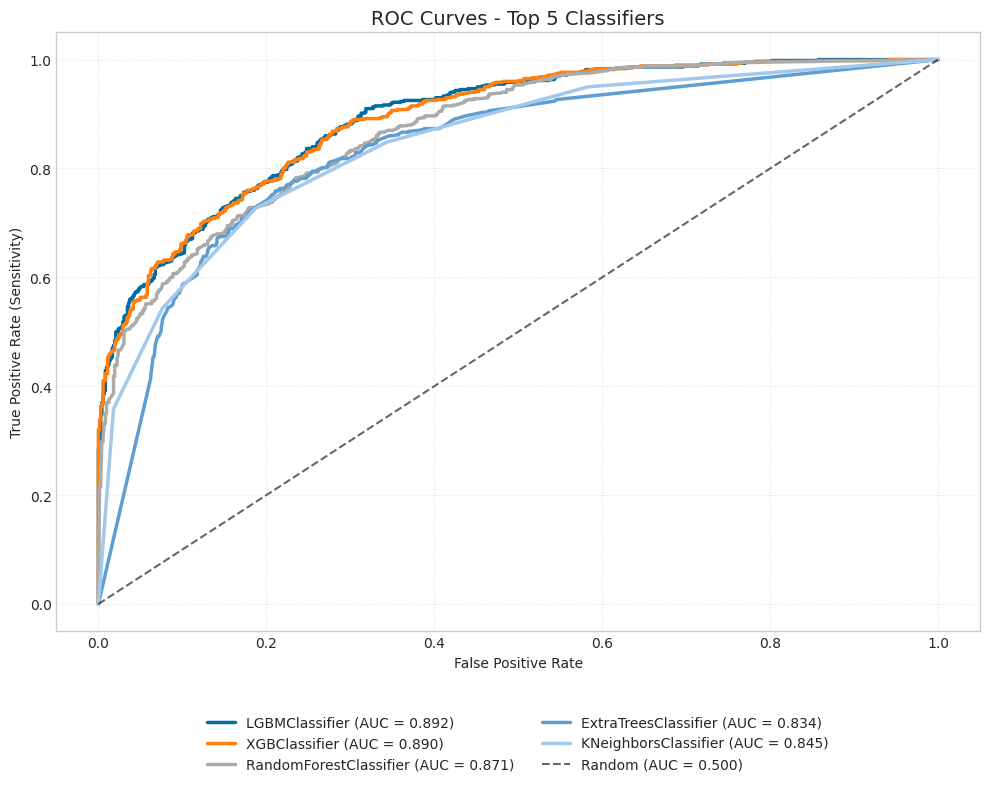

In [108]:
from sklearn.metrics import roc_curve, auc

# 1. Setup Parameters
N = 5
top_N_models = scores.head(N).index.tolist()

# 2. Configure Discrete High-Contrast Colors
cmap = load_cmap("Classic_Color_Blind")
# We skip the "muddy" mid-tones to ensure high visual separation
contrast_indices = [0, 1, 2, 4, 7] 
colors_roc = [cmap(i) for i in contrast_indices]

fig, ax = plt.subplots(figsize=(10, 8))

# 3. Plot Model Curves
for idx, model_name in enumerate(top_N_models):
    model = clf.models[model_name]
    
    # Probability/Decision Function handling
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        # Handle decision_function (e.g., SVM/Linear models)
        y_pred_proba = model.decision_function(X_test)
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Use modulo just in case N > length of contrast_indices
    ax.plot(fpr, tpr, 
            label=f'{model_name} (AUC = {roc_auc:.3f})', 
            color=colors_roc[idx % len(colors_roc)], 
            linewidth=2.5) # Slightly thicker for better visibility

# 4. Baseline and Formatting
ax.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.6, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves - Top 5 Classifiers', fontsize=14)

# Keeping dimensions and location strictly as requested
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig((os.path.join(str(save_path), f'top_{N}_models_roc_curves.pdf')), dpi=300, bbox_inches='tight')
plt.show()


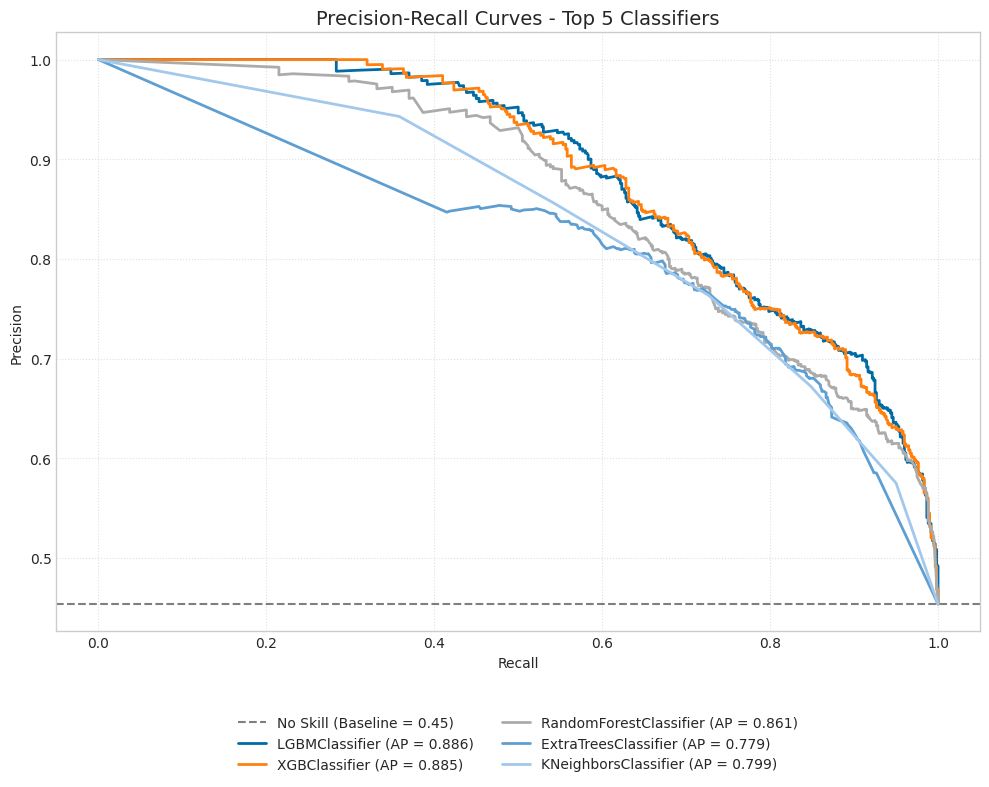

In [109]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Setup Palette
cmap = load_cmap("Classic_Color_Blind")
contrast_indices = [0, 1, 2, 4, 7]
colors_pr = [cmap(i) for i in contrast_indices]

fig, ax = plt.subplots(figsize=(10, 8))

# "No Skill" Baseline
# For PR curves, the "No Skill" baseline is the ratio of positive classes in the dataset.
no_skill = sum(y_test) / len(y_test)
ax.axhline(y=no_skill, color='black', linestyle='--', alpha=0.5, label=f'No Skill (Baseline = {no_skill:.2f})')

# Plot Model Curves
for idx, model_name in enumerate(top_N_models):
    model = clf.models[model_name]
    
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_pred_proba = model.decision_function(X_test)
    else:
        continue
    
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)
    
    ax.plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.3f})', 
            color=colors_pr[idx % len(colors_pr)], linewidth=2)

# Formatting and Details
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves - Top 5 Classifiers', fontsize=14)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig((os.path.join(str(save_path), f'top_{N}_models_precision_recall_curves.pdf')), dpi=300, bbox_inches='tight')
plt.show()

In [110]:
model_families_clf = {
    'Tree-based': ['ExtraTreesClassifier', 'RandomForestClassifier', 'GradientBoostingClassifier', 
                   'HistGradientBoostingClassifier', 'XGBClassifier', 'LGBMClassifier', 'DecisionTreeClassifier'],
    'SVM': ['SVC', 'NuSVC', 'LinearSVC'],
    'Linear': ['LogisticRegression', 'RidgeClassifier', 'SGDClassifier', 'Perceptron', 
               'PassiveAggressiveClassifier'],
    'Ensemble': ['AdaBoostClassifier', 'BaggingClassifier'],
    'Neighbors': ['KNeighborsClassifier', 'NearestCentroid'],
    'Naive Bayes': ['GaussianNB', 'BernoulliNB'],
    'Other': ['QuadraticDiscriminantAnalysis', 'LinearDiscriminantAnalysis']
}

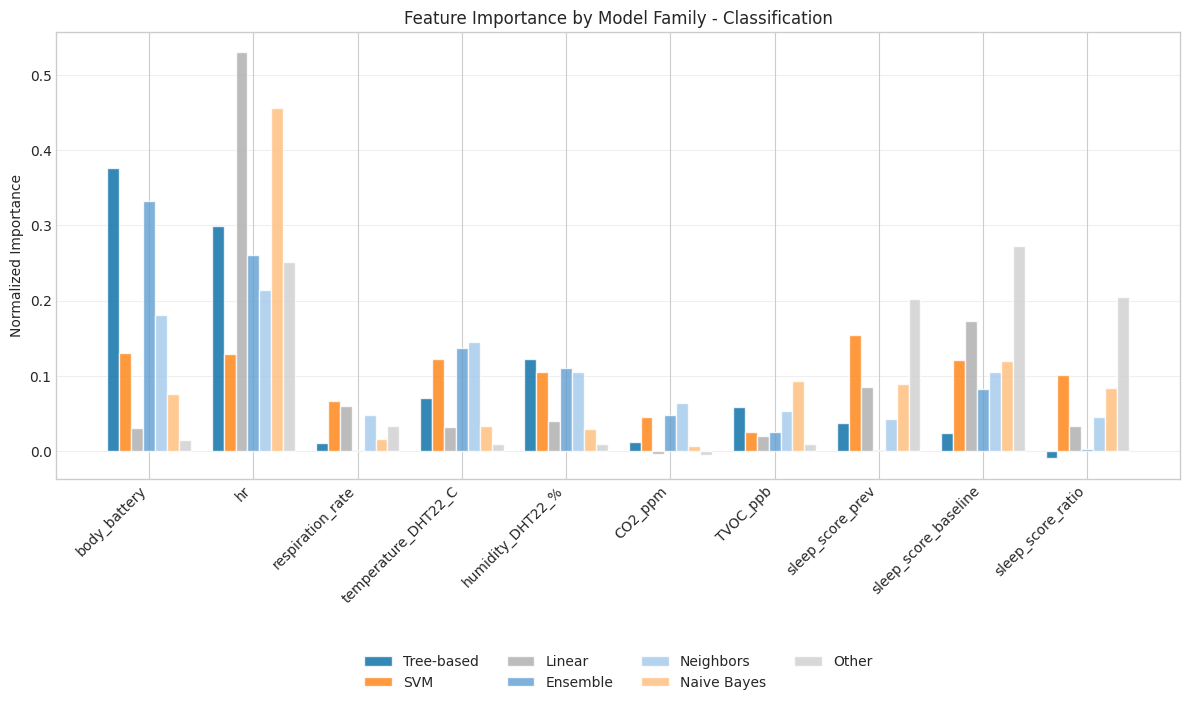

In [113]:
# 9. Feature Importance and Performance by Model Family - CLASSIFICATION
from sklearn.inspection import permutation_importance

best_per_family_clf = {}
for family, model_types in model_families_clf.items():
    for model_name in scores.index:
        if any(model_type in model_name for model_type in model_types):
            if family not in best_per_family_clf:
                best_per_family_clf[family] = {
                    'name': model_name,
                    'accuracy': scores.loc[model_name, 'Accuracy'],
                    'f1': scores.loc[model_name, 'F1 Score']
                }
            break

best_per_family_clf = {k: v for k, v in best_per_family_clf.items() if v}

# Selecting specific indices to avoid similar grays (skipping 3, 5, 6 etc. if they overlap)
contrast_indices = [0, 1, 2, 4, 7, 8, 9] 
colors_feat = [cmap(i) for i in contrast_indices]

n_families = len(best_per_family_clf)
fig, axes = plt.subplots(1, figsize=(12, 8))

ax1 = axes
x_pos = np.arange(len(FEATURES))
width = 0.8 / n_families

for idx, (family, info) in enumerate(best_per_family_clf.items()):
    model_name = info['name']
    model = clf.models[model_name]
    
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    else:
        result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42)
        importances = result.importances_mean
    
    importances = importances / importances.sum()
    
    offset = (idx - n_families/2) * width + width/2
    # Apply discrete color selection
    ax1.bar(x_pos + offset, importances, width, label=f'{family}', 
            color=colors_feat[idx % len(colors_feat)], alpha=0.8)

ax1.set_ylabel('Normalized Importance')
ax1.set_title('Feature Importance by Model Family - Classification')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(FEATURES, rotation=45, ha='right')
ax1.legend(bbox_to_anchor=(0.5, -0.5), loc='lower center', ncol=4, frameon=False)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig((os.path.join(str(save_path), f'feature_importance_by_family_classification.pdf')), dpi=300, bbox_inches='tight')
plt.show()

## 🏠 Stress Behavior Across Different Rooms - Same User Analysis

Visualize how stress levels change for a single user across different rooms/locations:

Box plot & violin plot - Stress distribution by room

Heatmap - Hourly stress pattern by room

In [52]:
# # 3. HEATMAP - Hour of Day vs Room (same user)
# # Crea pivot table: hours vs rooms
# user_room_data['hour'] = user_room_data['timestamp_local'].dt.hour
# pivot_stress = user_room_data.pivot_table(values='stress_score', 
#                                          index='hour', 
#                                          columns='room', 
#                                          aggfunc='mean')

# fig, ax = plt.subplots(figsize=(12, 8))
# sns.heatmap(pivot_stress, cmap='RdYlGn_r', annot=True, fmt='.1f', 
#            cbar_kws={'label': 'Avg Stress Score'}, ax=ax, 
#            linewidths=0.5, linecolor='gray')
# ax.set_title(f'🔥 Hourly Stress Pattern by Room - User {target_user}', 
#             fontsize=14, fontweight='bold')
# ax.set_xlabel('Room', fontsize=12, fontweight='bold')
# ax.set_ylabel('Hour of Day', fontsize=12, fontweight='bold')
# plt.tight_layout()
# plt.show()

# print(f"\n🗺️ Average Stress by Hour and Room - User {target_user}")
# print(pivot_stress.round(2))


Radar charts - 24-hour stress cycles for each room

Bar chart - Mean stress by room with standard deviation

### Predict 5-minute Stress Class and Room Breakdown
Train a simple RandomForest classifier to predict 5-minute-ahead stress classes, then summarize each room by the predicted class distribution for the most active user.

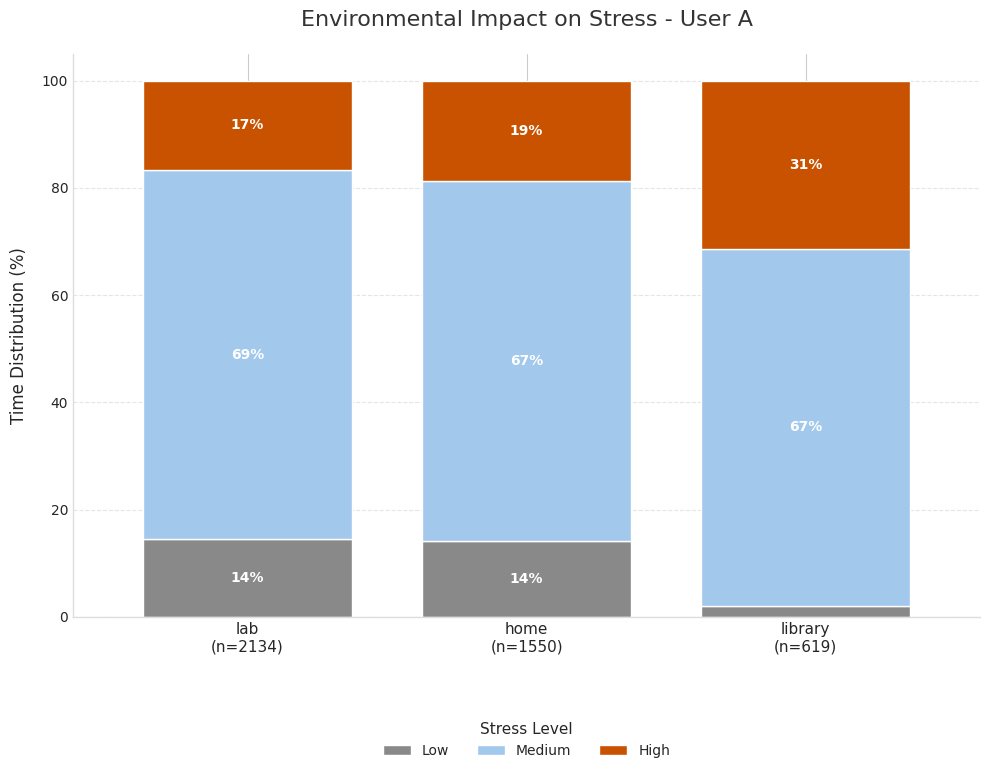

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Ensure timestamps are datetime
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'])
df = df.sort_values('timestamp_local')

# Classification
def classify_stress(score):
    if score <= 25: return 'Low'
    elif score <= 60: return 'Medium'
    else: return 'High'

# Future target (5 min)
horizon = pd.Timedelta(minutes=5)
df_target = df[['timestamp_local', 'garmin_id', 'stress_score']].copy()
df_target['timestamp_match'] = df_target['timestamp_local'] - horizon

df_labeled = pd.merge_asof(
    df,
    df_target[['timestamp_match', 'garmin_id', 'stress_score']],
    left_on='timestamp_local',
    right_on='timestamp_match',
    by='garmin_id',
    direction='nearest',
    tolerance=pd.Timedelta(minutes=1),
    suffixes=('', '_future')
)

df_labeled = df_labeled.dropna(subset=['stress_score_future'])
df_labeled['target_class'] = df_labeled['stress_score_future'].apply(classify_stress)

# Training
features = ['body_battery', 'hr', 'temperature_DHT22_C', 'humidity_DHT22_%', 'CO2_ppm']
X = df_labeled[features].fillna(0)
y = df_labeled['target_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

df_labeled['pred_class_5min'] = clf.predict(X)

# Strict categorical order
class_order = ['Low', 'Medium', 'High']
df_labeled['pred_class_5min'] = pd.Categorical(df_labeled['pred_class_5min'], categories=class_order, ordered=True)

# Identify target user
user_room_counts = df_labeled.groupby('garmin_id')['room'].nunique()
target_user = user_room_counts.idxmax()
num_rooms = user_room_counts.max()

# Filter user data
user_df = df_labeled[df_labeled['garmin_id'] == target_user].copy()

# Compute percentages
stress_dist = user_df.groupby(['room', 'pred_class_5min'], observed=False).size().unstack(fill_value=0)

# --- IMPROVEMENT 1: Filter Significant Rooms ---
# Exclude rooms where the user has very few observations (less than 10),
# to avoid odd columns with 100% based on a single data point.
total_counts = stress_dist.sum(axis=1)
valid_rooms = total_counts[total_counts > 10].index
stress_dist = stress_dist.loc[valid_rooms]
total_counts = total_counts.loc[valid_rooms]  # Update counts for labels

# Compute normalized percentages
stress_props = stress_dist.div(stress_dist.sum(axis=1), axis=0) * 100

# --- IMPROVEMENT 2: Order by "Stress" ---
# Order bars so the most stressful rooms (more 'High') are on the right
stress_props = stress_props.sort_values(by=['High', 'Medium'], ascending=True)

# --- PLOTTING STYLE ---
# Set a clean style
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8))

# --- IMPROVEMENT 3: Custom Colors (Colorblind-friendly) ---
# Low, Medium, High stress - using colorblind-safe palette
custom_colors = [cmap(0.6), cmap(0.7), cmap(0.5)]

ax = stress_props.plot(
    kind='bar',
    stacked=True,
    color=custom_colors,
    width=0.75,
    edgecolor='white',  # White border between segments for cleanliness
    linewidth=1,
    figsize=(10, 8),
    ax=plt.gca()  # Use current axis
)

# Titles and labels
plt.title(f"Environmental Impact on Stress - User A", fontsize=16, pad=20, color='#333333')
plt.ylabel("Time Distribution (%)", fontsize=12, labelpad=10)
plt.xlabel("", fontsize=12)  # Remove generic x label, use room names

# --- IMPROVEMENT 4: Richer X-axis Labels ---
# Add sample count (n) under the room name
labels = [f"{room}\n(n={total_counts[room]})" for room in stress_props.index]
ax.set_xticklabels(labels, rotation=0, fontsize=11)

# Clean legend
plt.legend(
    title="Stress Level",
    title_fontsize='11',
    fontsize='10',
    bbox_to_anchor=(0.5, -0.15),
    loc='upper center',
    borderpad=1,
    ncol=3
)

# Grid and borders
plt.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')

# --- Percentage Labels ---
for c in ax.containers:
    # Show label only if the segment is large enough (>5%) to be readable
    labels = [f'{v.get_height():.0f}%' if v.get_height() > 5 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig((os.path.join(str(save_path), 'stress_distribution_by_room.pdf')), dpi=300, bbox_inches='tight')
plt.show()


### Upcoming Step: Automatic Room-Based Stress Comparison
The next cell selects the most shared room during work hours, identifies the top two users in that room, aggregates hourly stress averages, and plots a side-by-side line/area comparison to highlight differences across the day.

--- AUTOMATIC ANALYSIS ---
Selected room: lab
Users compared: 66c2c60b-769f-4d63-b470-a3ae5c6ed251 vs 8d738deb-db44-405e-ac6a-ce73135eb434


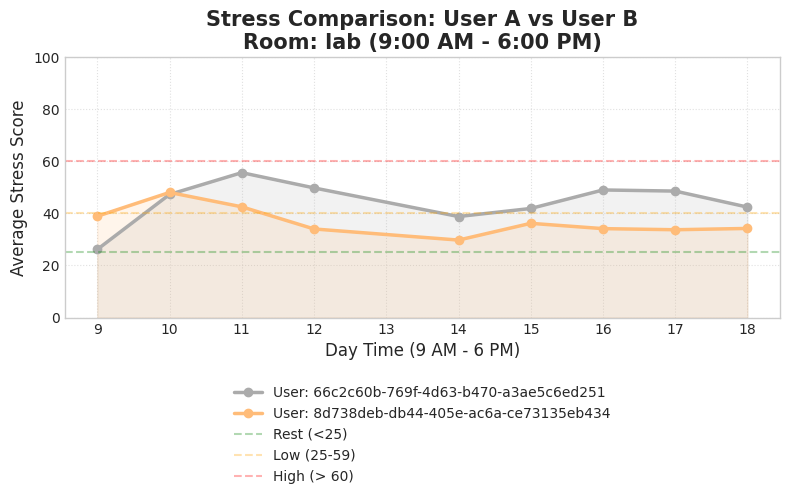

In [54]:
# --- DATA PREPARATION ---
# Ensure timestamps are datetime
df_labeled['timestamp_local'] = pd.to_datetime(df_labeled['timestamp_local'])

# General time filter (9-18) for analysis
work_hours_df = df_labeled[
    (df_labeled['timestamp_local'].dt.hour >= 9) &
    (df_labeled['timestamp_local'].dt.hour <= 18)
].copy()

if work_hours_df.empty:
    print("No data in the 9-18 time window.")
else:
    # --- AUTOMATIC SELECTION (SMART SEARCH) ---
    
    # Count unique users for each room
    room_stats = work_hours_df.groupby('room')['garmin_id'].nunique()
    
    # Keep only rooms with at least 2 users
    shared_rooms = room_stats[room_stats >= 2].index.tolist()
    
    if not shared_rooms:
        print("There are no rooms with at least 2 users in this time window.")
    else:
        # Among shared rooms, choose the one with the most total rows
        # to have the most reliable chart
        best_room = work_hours_df[work_hours_df['room'].isin(shared_rooms)]['room'].value_counts().idxmax()
        
        # Identify the top two users in this room
        room_data = work_hours_df[work_hours_df['room'] == best_room]
        top_users = room_data['garmin_id'].value_counts().head(2).index.tolist()
        
        print(f"--- AUTOMATIC ANALYSIS ---")
        print(f"Selected room: {best_room}")
        print(f"Users compared: {top_users[0]} vs {top_users[1]}")
        
        # --- DATA AGGREGATION ---
        # Filter only the selected room and users
        plot_df = room_data[room_data['garmin_id'].isin(top_users)].copy()
        
        # Extract hour (0-23)
        plot_df['hour_int'] = plot_df['timestamp_local'].dt.hour
        
        # Mean by hour and user
        hourly_comparison = (
            plot_df.groupby(['hour_int', 'garmin_id'])['stress_score']
            .mean()
            .reset_index()
        )
        
        # --- PLOTTING ---
        plt.figure(figsize=(8, 6))
        colors = [cmap(0.2), cmap(0.8)] 

        for i, user in enumerate(top_users):
            user_curve = hourly_comparison[hourly_comparison['garmin_id'] == user].sort_values('hour_int')
            
            if user_curve.empty:
                continue
                
            # Line
            plt.plot(
                user_curve['hour_int'],
                user_curve['stress_score'],
                marker='o',
                linewidth=2.5,
                label=f"User: {user}",
                color=colors[i]
            )
            
            # Area
            plt.fill_between(
                user_curve['hour_int'],
                user_curve['stress_score'],
                alpha=0.15,
                color=colors[i]
            )

        # Decorations
        plt.title(f"Stress Comparison: User A vs User B\nRoom: {best_room} (9:00 AM - 6:00 PM)", fontsize=15, fontweight='bold')
        plt.xlabel("Day Time (9 AM - 6 PM)", fontsize=12)
        plt.ylabel("Average Stress Score", fontsize=12)
        plt.xticks(range(9, 19))
        plt.ylim(0, 100)
        
        # Thresholds
        plt.axhline(y=25, color='green', linestyle='--', alpha=0.3, label='Rest (<25)')
        plt.axhline(y=40, color='orange', linestyle='--', alpha=0.3, label='Low (25-59)')
        plt.axhline(y=60, color='red', linestyle='--', alpha=0.3, label='High (> 60)')

        plt.grid(True, axis='both', linestyle=':', alpha=0.6)
        plt.legend(bbox_to_anchor=(0.5, -0.45), loc='center', ncol=1)
        plt.tight_layout()
        plt.savefig((os.path.join(str(save_path), 'stress_comparison_by_hour.pdf')), dpi=300, bbox_inches='tight')
        plt.show()


### Next Step

The next cell will focus on a focused room-level analysis for the selected user, aggregating hourly stress trends within the most visited rooms and visualizing how stress evolves across the workday.

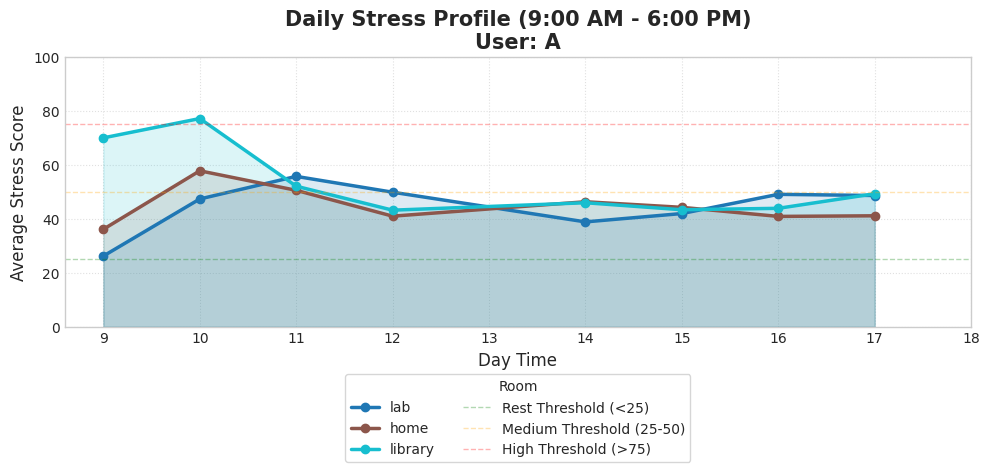

In [55]:
# --- DATA PREPARATION ---
# Ensure timestamps are datetime
df_labeled['timestamp_local'] = pd.to_datetime(df_labeled['timestamp_local'])

# Filter for the target user
user_df = df_labeled[df_labeled['garmin_id'] == target_user].copy()

# Time window filter 9-18
user_df = user_df[(user_df['timestamp_local'].dt.hour >= 9) & (user_df['timestamp_local'].dt.hour < 18)].copy()

if user_df.empty:
    print("No data between 9 and 18 for the selected user.")
else:
    # 1. HOUR EXTRACTION (Integer 0-23 only, no date)
    user_df['hour_int'] = user_df['timestamp_local'].dt.hour

    # 2. TOP ROOMS SELECTION
    top_rooms = user_df['room'].value_counts().head(4).index.tolist()
    
    # 3. AGGREGATION
    # Compute average stress for each hour of the day in each room
    hourly_room = (
        user_df[user_df['room'].isin(top_rooms)]
        .groupby(['hour_int', 'room'])['stress_score']
        .mean()
        .reset_index()
    )

    # --- PLOTTING ---
    plt.figure(figsize=(10, 5))
    
    # Define distinct colors for rooms for clarity
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_rooms)))

    for i, room in enumerate(top_rooms):
        room_data = hourly_room[hourly_room['room'] == room].sort_values('hour_int')
        
        if room_data.empty:
            continue
            
        # Plot the average line
        plt.plot(
            room_data['hour_int'], 
            room_data['stress_score'], 
            marker='o', 
            linewidth=2.5, 
            label=room,
            color=colors[i]
        )
        
        # Shaded area: instead of filling to 0 (which clutters the chart),
        # fill just under the curve to add visual weight while keeping readability
        plt.fill_between(
            room_data['hour_int'], 
            room_data['stress_score'], 
            alpha=0.15, 
            color=colors[i]
        )

    # --- AESTHETIC FORMATTING ---
    plt.title(f"Daily Stress Profile (9:00 AM - 6:00 PM)\nUser: A", fontsize=15, fontweight='bold')
    plt.xlabel("Day Time", fontsize=12)
    plt.ylabel("Average Stress Score", fontsize=12)
    
    # Set X-axis to show only integer hours
    plt.xticks(range(9, 19))
    
    # Y-axis limits consistent with Garmin stress (0-100)
    plt.ylim(0, 100)
    
    # Add reference bands (optional but useful for context)
    plt.axhline(y=25, color='green', linestyle='--', alpha=0.3, linewidth=1, label='Rest Threshold (<25)')
    plt.axhline(y=50, color='orange', linestyle='--', alpha=0.3, linewidth=1, label='Medium Threshold (25-50)')
    plt.axhline(y=75, color='red', linestyle='--', alpha=0.3, linewidth=1, label='High Threshold (>75)')

    plt.grid(True, axis='both', linestyle=':', alpha=0.6)
    plt.legend(title="Room", bbox_to_anchor=(0.5, -0.15), loc='upper center', frameon=True, ncol=2)
    
    plt.tight_layout()
    plt.show()


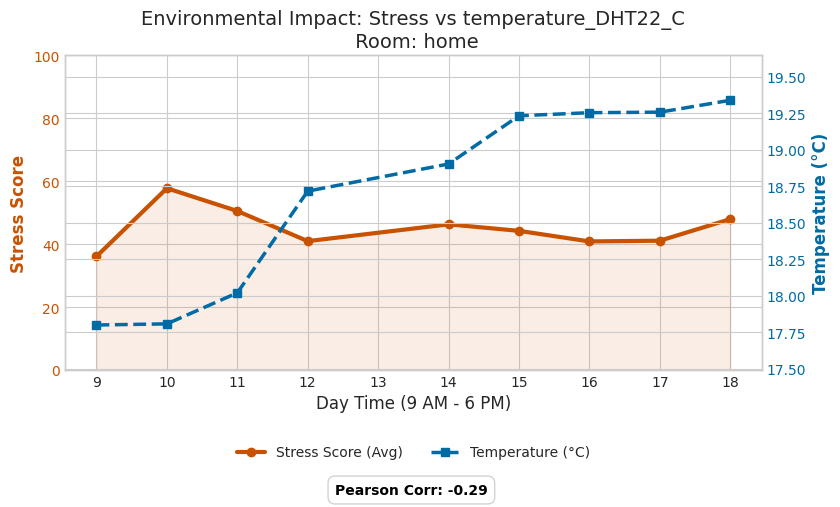

In [114]:
# --- CONFIGURATION ---
# Choose the room you want to analyze (e.g., the one with the highest stress)
target_room_analysis = 'home'  # Change to 'lab', 'library', etc.
# Choose the feature you want to compare
target_feature = 'temperature_DHT22_C'        # Options: 'humidity_DHT22_%', 'temperature_DHT22_C', 'CO2_ppm', 'TVOC_ppb'
feature_label = 'Temperature (°C)'  # Label for the chart

# --- DATA PREPARATION ---
# Base filters (User + 9-18 Time Window + Specific Room)
analysis_df = df_labeled[
    (df_labeled['garmin_id'] == target_user) &
    (df_labeled['room'] == target_room_analysis) &
    (df_labeled['timestamp_local'].dt.hour >= 9) &
    (df_labeled['timestamp_local'].dt.hour <= 18)
].copy()

if analysis_df.empty:
    print(f"No data for {target_room_analysis} in the specified time window.")
else:
    analysis_df['hour_int'] = analysis_df['timestamp_local'].dt.hour

    # Aggregation: compute average stress and feature values
    hourly_analysis = (
        analysis_df.groupby('hour_int')[['stress_score', target_feature]]
        .mean()
        .reset_index()
    )

    # --- CORRELATION CALCULATION ---
    correlation = hourly_analysis['stress_score'].corr(hourly_analysis[target_feature])
    corr_text = f"Correlation: {correlation:.2f}"
    
    # Correlation color (Green if positive, Red if negative, Gray if weak)
    if correlation > 0.5:
        corr_color = 'green'  # Feature increases -> Stress increases
    elif correlation < -0.5:
        corr_color = 'red'    # Feature increases -> Stress decreases
    else:
        corr_color = 'gray'

    # --- PLOTTING ---
color_stress = cmap(5)   
color_feature = cmap(0)  # Distinct cool tone

fig, ax1 = plt.subplots(figsize=(8.5, 5))

# 1. Stress plot (Left Y-axis - Solid)
ax1.plot(hourly_analysis['hour_int'], hourly_analysis['stress_score'],
         color=color_stress, marker='o', linewidth=3, label='Stress Score (Avg)')
ax1.fill_between(hourly_analysis['hour_int'], hourly_analysis['stress_score'],
                 color=color_stress, alpha=0.1)

ax1.set_xlabel('Day Time (9 AM - 6 PM)', fontsize=12)
ax1.set_ylabel('Stress Score', fontsize=12, color=color_stress, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_stress)
ax1.set_ylim(0, 100)
ax1.set_xticks(range(9, 19))

# 2. Environmental feature plot (Right Y-axis - Dashed)
ax2 = ax1.twinx()

ax2.plot(hourly_analysis['hour_int'], hourly_analysis[target_feature],
         color=color_feature, marker='s', linestyle='--', linewidth=2.5, label=feature_label)

ax2.set_ylabel(feature_label, fontsize=12, color=color_feature, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_feature)

# Set feature limits with a small margin
f_min, f_max = hourly_analysis[target_feature].min(), hourly_analysis[target_feature].max()
margin = (f_max - f_min) * 0.2 if f_max != f_min else 1
ax2.set_ylim(f_min - margin, f_max + margin)

# --- FINAL FORMATTING ---
plt.title(f"Environmental Impact: Stress vs {target_feature}\n Room: {target_room_analysis}",
          fontsize=14)

# Correlation box - using a neutral black or the corr_color logic
plt.figtext(0.4, 0, f"Pearson Corr: {correlation:.2f}",
            bbox=dict(facecolor='white', edgecolor='lightgray', boxstyle='round,pad=0.5'),
            fontsize=10, color='black', fontweight='bold')

# Merge legends (Removed box with frameon=False for consistency with your style)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, 
           loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)

plt.grid(True, axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig((os.path.join(str(save_path), f'environmental_impact_{target_room_analysis}_{target_feature}.pdf')), dpi=300, bbox_inches='tight')
plt.show()